📖 개념: —

❓ 확인할 것: OHLCV가 실제로 어떻게 생겼는지

### ① 삼성전자(`005930`) 최근 1년치 일봉 받기

힌트: `from pykrx import stock` → `stock.get_market_ohlcv(시작일, 종료일, 종목코드)` · 날짜는 `"20251001"` 형식

("KRX 로그인 실패" 메시지는 무시해도 됨)

In [52]:
from pykrx import stock
dir(stock)                        # pykrx로 할 수 있는 함수 목록
help(stock.get_market_ohlcv)      # 이 함수에 뭘 넣어야 하는지 설명

Help on function get_market_ohlcv in module pykrx.stock.stock_api:

get_market_ohlcv(*args, **kwargs)
    OHLCV 조회
    Args:
    
        특정 종목의 지정된 기간 OHLCV 조회
    
        fromdate     (str           ): 조회 시작 일자 (YYYYMMDD)
        todate       (str           ): 조회 종료 일자 (YYYYMMDD)
        ticker       (str,  optional): 조회할 종목의 티커
        freq         (str,  optional): d - 일 / m - 월 / y - 년
        adjusted     (bool, optional): 수정 종가 여부 (True/False)
    
        특정 일자의 전종목 OHLCV 조회
    
        date   (str): 조회 일자 (YYYYMMDD)
        market (str): 조회 시장 (KOSPI/KOSDAQ/KONEX/ALL)
    
    Returns:
        DataFrame:
    
            특정 종목의 지정된 기간 OHLCV 조회
            >> get_market_ohlcv("20210118", "20210126", "005930")
    
                         시가   고가   저가   종가    거래량
            날짜
            2021-01-18  86600  87300  84100  85000  43227951
            2021-01-19  84500  88000  83600  87000  39895044
            2021-01-20  89000  89000  86500  87200  25211127
            2021-0

In [53]:
## 종목코드
import FinanceDataReader as fdr
krx = fdr.StockListing("KRX")        # 한국 전체 종목 목록
krx[krx["Name"] == "SK하이닉스"]      # → Code 칸에 000660
krx[krx["Name"] == "삼성전자"]      

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId,lateInfoMsgCd
0,005930,KR7005930003,삼성전자,KOSPI,NaN,276000,3,0,0.0,273500,277000,271500,11399309,3139338287000,1613572895808000,5846278608,STK,ME006


In [54]:
## 삼성전자 251001~260930 주가
df = stock.get_market_ohlcv("20251001", "20260930", "005930")
df

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2025-10-01,84900,86200,84700,86000,22039361,2.502980
2025-10-02,89300,90300,88700,89000,49883028,3.488372
2025-10-10,94000,94500,92700,94400,35269748,6.067416
2025-10-13,91300,93400,90700,93300,23883308,-1.165254
2025-10-14,95300,96000,90200,91600,35545235,-1.822079
...,...,...,...,...,...,...
2026-09-22,283000,283500,271500,277500,18157410,0.909091
2026-09-23,284500,286500,281000,286500,20864376,3.243243
2026-09-28,284500,285500,268500,270000,21346064,-5.759162


### ② 처음 5줄, 마지막 5줄 보기

힌트: `df.head()`, `df.tail()`

In [55]:
df.head()

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2025-10-01,84900,86200,84700,86000,22039361,2.502980
2025-10-02,89300,90300,88700,89000,49883028,3.488372
2025-10-10,94000,94500,92700,94400,35269748,6.067416
2025-10-13,91300,93400,90700,93300,23883308,-1.165254
2025-10-14,95300,96000,90200,91600,35545235,-1.822079


In [56]:
df.tail()

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-09-22,283000,283500,271500,277500,18157410,0.909091
2026-09-23,284500,286500,281000,286500,20864376,3.243243
2026-09-28,284500,285500,268500,270000,21346064,-5.759162
2026-09-29,266000,276000,266000,275000,15963864,1.851852
2026-09-30,274500,276000,267500,269500,16477580,-2.000000


### ③ 몇 행 몇 열? 1년이 며칠?

힌트: `df.shape` → 365보다 적다면 왜?

In [57]:
df.shape

## (241,6)
# 241행 = 241일치 데이터. 하루가 한 줄 (주식 시장 열린날만 데이터 존재(주말,공휴일등 제외))
# 6열 = 컬럼 6개. 시가, 고가, 저가, 종가, 거래량, 등락률

(241, 6)

### ④ 컬럼마다 뭐가 들어 있나

힌트: `df.columns`, `df.dtypes` · 시가 / 고가 / 저가 / 종가 / 거래량 / 등락률

In [58]:
df.columns

Index(['시가', '고가', '저가', '종가', '거래량', '등락률'], dtype='object')

In [59]:
df.dtypes

시가       int64
고가       int64
저가       int64
종가       int64
거래량      int64
등락률    float64
dtype: object

### ⑤ 종가 그래프 그리기

힌트: `df["종가"].plot()` · 크게 튄 날이 있으면 그날 무슨 일이 있었는지?

<Axes: xlabel='날짜'>

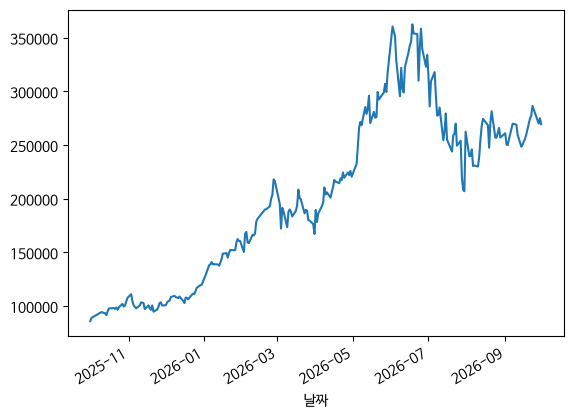

In [60]:
df["종가"].plot()

### ⑥ 빠진 날이나 이상한 값이 있나

힌트: `df.isna().sum()`, `df.describe()` · 거래량이 0인 날은?

In [61]:
df.isna().sum()
# 모두 0으로 빠진 데이터 없음

시가     0
고가     0
저가     0
종가     0
거래량    0
등락률    0
dtype: int64

In [62]:
df.describe()

,시가,고가,저가,종가,거래량,등락률
count,241.00000,241.000000,241.000000,241.000000,2.410000e+02,241.000000
mean,203807.46888,208733.402490,198579.668050,203632.365145,2.740873e+07,0.599978
std,77539.55030,80209.269093,74241.642217,77199.295321,1.068526e+07,4.830110
min,84900.00000,86200.000000,84700.000000,86000.000000,1.090553e+07,-13.385827
25%,134600.00000,138600.000000,132700.000000,137600.000000,1.988448e+07,-1.892042
50%,202500.00000,207500.000000,199600.000000,203500.000000,2.485917e+07,0.804829
75%,267000.00000,272000.000000,260000.000000,268500.000000,3.353017e+07,3.218391
max,372500.00000,374500.000000,352000.000000,362500.000000,8.942795e+07,26.811594


## ➕ 더 궁금한 것 (대화 중에 나온 질문)

### ⑦ 가장 크게 오른 날 / 내린 날은 언제?

`describe()`에서 등락률 max **+26.8%**, min **-13.4%** — 삼성전자치고 너무 큼.

힌트: `df["등락률"].idxmax()`, `df["등락률"].idxmin()` → 그날 뉴스 검색해보기

- 진짜 뉴스가 있다 → "뉴스는 차트에 결과로만 남는다"
- 아무 일도 없다 → 데이터 오류 의심 (전처리 점검)

In [63]:
df["등락률"].max(), df["등락률"].idxmax()

(np.float64(26.811594202898554), Timestamp('2026-07-31 00:00:00'))

In [64]:
df["등락률"].min(), df["등락률"].idxmin()

(np.float64(-13.385826771653544), Timestamp('2026-07-28 00:00:00'))

#### 🔍 그날 무슨 일이? (Claude가 뉴스 검색, 2026-10-04)

**그 주 흐름** (pykrx로 확인)

| 날짜 | 종가 | 등락률 | 거래량 |
|---|---|---|---|
| 7/24 (금) | 249,500 | −7.6% | 2,618만 |
| 7/27 (월) | 254,000 | +1.8% | 2,330만 |
| **7/28 (화)** | **220,000** | **−13.4%** ← 최대 하락 | **4,164만** |
| 7/29 (수) | 208,500 | −5.2% | **6,556만** |
| 7/30 (목) | 207,000 | −0.7% | 4,669만 |
| **7/31 (금)** | **262,500** | **+26.8%** ← 최대 상승 | **5,848만** |
| 8/3 (월) | 239,500 | −8.8% | 2,783만 |

→ 두 날은 **사흘 간격**. 거래량이 평소(평균 약 2,700만)의 1.5~2.5배로 터짐.

**7/28 −13.4% — 시장 전체 폭락**
- 코스피 −8%, **서킷브레이커** 발동 (시장 급락 시 거래를 잠시 멈추는 장치)
- 원인으로 꼽힌 것: 중국 D램 업체 **CXMT 상장**(경쟁 우려) · **AI 투자 붐 지속 여부** 의심 → 반도체주 차익실현 · 중국 노광장비 개발 소식
- 삼성전자 자체 문제라기보다 **반도체 업종 전체에 대한 공포**

**7/31 +26.8% — 급반등**
- 4거래일 하락을 끊고 반등. SK하이닉스도 같이 급등 ("투톱 급등 랠리")
- 꼽힌 이유: 과매도 상태에서의 반등 · 반도체 업황 기대(HBM 점유율, 2분기 실적) 회복
- ⚠️ 기사마다 다름 — 한 매체는 **"뚜렷한 호재 없이 26%대 폭등"**. 한 가지 뉴스로 단정하기 어려움

**출처**
- [반도체주 급락 원인 (다음)](https://v.daum.net/v/20260728100616889) · [오늘 왜 폭락했나 (Investing.com)](https://kr.investing.com/news/stock-market-news/article-93CH-2031438)
- [투톱 급등 랠리 (CBC뉴스)](https://www.cbci.co.kr/news/articleView.html?idxno=593584) · [뚜렷한 호재 없이 26%대 폭등 (재경일보)](https://news.jkn.co.kr/post/951581) · [오늘 급등한 이유 (Investing.com)](https://kr.investing.com/news/stock-market-news/article-93CH-2036000)

**연습 관점에서**
1. 데이터 오류가 아니라 **진짜 이벤트** → 이상치라고 함부로 지우면 안 됨
2. 7/28은 **과거 차트에 없는 정보**(중국 업체 상장, 시장 공포) → 차트만으로는 예측 어려움
3. 7/31은 "많이 떨어진 뒤 반등"이라는 **차트 패턴**으로 설명될 여지 있음
4. 시장 전체가 같이 움직이는 날이 있음 → 코스피 지수를 입력으로 같이 넣을 근거


### ⑧ `freq` 옵션 — 일봉 말고 월봉·연봉으로 받으면?

`help`에 나온 `freq`: `"d"` 일 / `"m"` 월 / `"y"` 년

힌트: `stock.get_market_ohlcv("20251001", "20260930", "005930", freq="m")` → `shape`가 몇 줄로 바뀌나?

In [65]:
stock.get_market_ohlcv("20251001","20260930","005930",freq="m")

,시가,고가,저가,종가,거래량
날짜,,,,,
2025-10-31,84900,108600,84700,107500,484630984
2025-11-30,106900,112400,94500,100500,472946077
2025-12-31,102000,121200,99900,119900,389028028
2026-01-31,120200,166600,120200,160500,649829602
2026-02-28,155700,223000,150400,216500,538540611
2026-03-31,209500,212500,167000,167200,689928910
2026-04-30,179000,230000,175000,220500,534763797
2026-05-31,228000,323000,224000,317000,622815748
2026-06-30,319500,374500,287500,334000,704005604


### ⑨ 일봉으로 월봉을 직접 만들 수 있나? (리샘플링)

컬럼마다 합치는 방법이 다름: 시가=첫날, 고가=최대, 저가=최소, 종가=마지막날, 거래량=합계

힌트: `df.resample("ME").agg({"시가": "first", "고가": "max", "저가": "min", "종가": "last", "거래량": "sum"})`

→ ⑧에서 받은 월봉이랑 **같은지** 비교해보기

In [66]:
df.resample("ME").agg({"시가": "first", "고가": "max", "저가": "min", "종가": "last", "거래량": "sum"})

,시가,고가,저가,종가,거래량
날짜,,,,,
2025-10-31,84900,108600,84700,107500,484630984
2025-11-30,106900,112400,94500,100500,472946077
2025-12-31,102000,121200,99900,119900,389028028
2026-01-31,120200,166600,120200,160500,649829602
2026-02-28,155700,223000,150400,216500,538540611
2026-03-31,209500,212500,167000,167200,689928910
2026-04-30,179000,230000,175000,220500,534763797
2026-05-31,228000,323000,224000,317000,622815748
2026-06-30,319500,374500,287500,334000,704005604


### ⑩ 수정주가(`adjusted`)를 켜고 끄면 뭐가 달라지나?

삼성전자는 **2018년 5월 50:1 액면분할** → 2018년 구간으로 비교하면 차이가 보일 것

힌트: `stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=False)` 와 `adjusted=True` 를 각각 받아서 종가 그래프 비교

In [67]:
stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=False)

,시가,고가,저가,종가,거래량,거래대금,등락률
날짜,,,,,,,
2018-04-02,2450000,2461000,2425000,2427000,142313,346383448000,-1.38
2018-04-03,2394000,2407000,2364000,2406000,255365,609108588000,-0.87
2018-04-04,2408000,2413000,2346000,2346000,247684,586682025000,-2.49
2018-04-05,2370000,2469000,2367000,2437000,264912,642625208000,3.88
2018-04-06,2400000,2429000,2370000,2420000,250654,603210892000,-0.70
2018-04-09,2413000,2472000,2410000,2460000,199008,488395543080,1.65
2018-04-10,2427000,2461000,2402000,2444000,219687,534757298912,-0.65
2018-04-11,2495000,2495000,2430000,2443000,201022,495246434000,-0.04
2018-04-12,2472000,2472000,2444000,2450000,249325,612210717000,0.29


In [68]:
stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=True) ## 기본은 True

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2018-04-02,49000,49220,48500,48540,142313,-1.381552
2018-04-03,47880,48140,47280,48120,255365,-0.865266
2018-04-04,48160,48260,46920,46920,247684,-2.493766
2018-04-05,47400,49380,47340,48740,264912,3.878943
2018-04-06,48000,48580,47400,48400,250654,-0.697579
2018-04-09,48260,49440,48200,49200,199008,1.652893
2018-04-10,48540,49220,48040,48880,219687,-0.650407
2018-04-11,49900,49900,48600,48860,201022,-0.040917
2018-04-12,49440,49440,48880,49000,249325,0.286533


### ⑪ 한국 ETF — KODEX 200(`069500`) 받기

KOSPI 200 지수를 따라가는 ETF (미국 `SPY` 같은 것)

- 일반 주식 함수: `stock.get_market_ohlcv(시작, 끝, "069500")`
- ETF 전용 함수: `stock.get_etf_ohlcv_by_date(시작, 끝, "069500")` (KRX 로그인 필요)

→ 두 결과의 컬럼 개수가 다름 (6 vs 8). ETF 전용에만 있는 컬럼은 뭐고 무슨 뜻?

In [69]:
stock.get_market_ohlcv("20251001","20260930","069500")

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2025-10-01,47370,47731,47370,47658,6095666,1.049552
2025-10-02,48815,49573,48643,49079,19845846,2.981661
2025-10-10,49999,50554,49678,50325,16114546,2.538764
2025-10-13,49285,49866,48905,49866,12685313,-0.912072
2025-10-14,50113,50835,48975,49360,18451583,-1.014719
...,...,...,...,...,...,...
2026-09-22,114345,114635,111400,111880,25168267,0.161146
2026-09-23,114290,114305,111945,113145,21157647,1.130676
2026-09-28,112740,112870,109500,109500,23611461,-3.221530


In [70]:
stock.get_etf_ohlcv_by_date("20251001","20260930", "069500")

,NAV,시가,고가,저가,종가,거래량,거래대금,기초지수
날짜,,,,,,,,
2025-10-01,48176.13,47845,48210,47845,48135,6035418,290046363244,479.37
2025-10-02,49579.47,49305,50070,49130,49570,19649694,977288053182,493.41
2025-10-10,50941.86,50500,51060,50175,50830,15955272,809539660474,506.97
2025-10-13,50431.38,49780,50365,49395,50365,12559935,629005194756,501.87
2025-10-14,49929.02,50615,51345,49465,49855,18269212,919623895029,496.89
...,...,...,...,...,...,...,...,...
2026-09-22,111926.48,114345,114635,111400,111880,25168267,2852398155211,1113.30
2026-09-23,113211.71,114290,114305,111945,113145,21157647,2387313148570,1126.12
2026-09-28,109503.88,112740,112870,109500,109500,23611461,2605660650256,1089.28


#### 🔍 두 결과가 미묘하게 다른 이유 — 분배금

| 함수 | 주는 가격 |
|---|---|
| `get_market_ohlcv` (주식 함수) | 분배금만큼 **과거 가격을 깎은 수정 가격** |
| `get_etf_ohlcv_by_date` (ETF 함수) | **실제로 거래된 가격** 그대로 (+ NAV, 거래대금, 기초지수) |

- ETF가 **분배금**(배당)을 주면 그 돈이 빠져나가서 가격이 그만큼 떨어짐 → 실제 가격만 보면 "하락"처럼 보이지만 투자자는 현금으로 받았으니 손해 아님
- 그래서 수정 가격은 **과거 가격을 그만큼 낮춰서** 가짜 하락이 안 생기게 이어 붙임 (삼성전자 액면분할 때 과거 가격을 50으로 나눈 것, 미국 `Close` vs `Adj Close`와 같은 원리)

**근거** — 두 종가의 비율(ETF 함수 ÷ 주식 함수)이 딱 네 번 내려감

| 날짜 | 비율 |
|---|---|
| ~ 2025-10-29 | 1.010 |
| 2025-10-30 | → 1.0075 |
| 2026-01-29 | → 1.0065 |
| 2026-04-29 | → 1.002 |
| 2026-07-30 | → 1.000 |

= KODEX 200 분배금 시기(**1·4·7·10월 말**)와 일치

- 7/30 이후로 두 가격이 같은 이유: 그 뒤(~9/30)로 분배금이 없어서 깎을 게 없음 (수정은 "이후에 있었던 분배금"만큼 과거를 깎는 것)
- 비율이 1.0075 ↔ 1.0076처럼 오락가락하는 건 원 단위 반올림 오차

**어떤 걸 쓸까** — 모델 입력·수익률 → 수정 가격(주식 함수) / 실제 거래 가격·NAV가 필요할 때 → ETF 함수


#### 📖 ETF 함수에만 있는 컬럼

| 컬럼 | 한 줄 요약 |
|---|---|
| NAV | ETF 안에 든 자산의 **실제 가치** (1주당) |
| 종가 | 시장에서 **실제 거래된 가격** → NAV와의 차이 = **괴리율** |
| 거래대금 | 그날 거래된 **돈의 총액** (거래량은 주식 수) |
| 기초지수 | ETF가 **따라가는 지수** 값 → 지수와의 차이 = **추적오차** |


### ⑫ 한국 지수 — KOSPI 200 받기 + ETF와 비교

힌트: `stock.get_index_ohlcv(시작, 끝, "1028")` (`1028` = KOSPI 200, KRX 로그인 필요)

- 지수 이름 확인: `stock.get_index_ticker_name("1028")`
- KOSPI 200 지수 vs KODEX 200 ETF: 가격 비율은? 첫날을 1로 맞춰 그리면 모양이 같나? (`data_load_us` ⑤ `^GSPC` vs `SPY`와 같은 구조)
- 참고: FinanceDataReader `fdr.DataReader("KS200")`도 되지만 9월 한 달이 13행만 나왔음 (거래일은 20일) → 빠진 날 있는지 비교해보기

In [71]:
stock.get_index_ohlcv("20251001","20260930", "1028")

코스피 200,시가,고가,저가,종가,거래량,거래대금,상장시가총액
날짜,,,,,,,
2025-10-01,477.16,479.81,476.49,479.37,89111956,8465683888338,2528144432814190
2025-10-02,491.25,498.22,489.53,493.41,160777307,16146295332382,2601843071314530
2025-10-10,504.20,508.52,500.49,506.97,168784344,16405367541664,2651382088461465
2025-10-13,496.45,501.87,492.46,501.87,135812608,11888268683972,2632445573343325
2025-10-14,505.46,511.59,493.06,496.89,161909306,14998001187994,2616222663926530
...,...,...,...,...,...,...,...
2026-09-22,1138.20,1141.18,1107.73,1113.30,118832738,20307973182599,5379081763617480
2026-09-23,1137.29,1137.56,1114.46,1126.12,122377451,19946029388597,5429715836924390
2026-09-28,1121.10,1123.34,1089.26,1089.28,120016925,20191784682367,5275539879885600


### ⑬ ETF 목록에서 찾기

힌트: `fdr.StockListing("ETF/KR")` (로그인 없이 됨, 약 1,170개) 또는 `stock.get_etf_ticker_list("20260930")`

- 나스닥 100을 따라가는 한국 ETF가 있나? → `Name`에 "나스닥"이 들어간 것: `etf[etf["Name"].str.contains("나스닥")]`
- S&P 500을 따라가는 한국 ETF는?

In [72]:
stock.get_etf_ticker_list("20260930")

['0193M0',
 '466810',
 '457930',
 '0218K0',
 '487750',
 '445690',
 '0120J0',
 '0112X0',
 '0191M0',
 '0222F0',
 '442260',
 '0001P0',
 '0229F0',
 '159800',
 '472840',
 '0005G0',
 '0178H0',
 '0135Y0',
 '0221V0',
 '0191S0',
 '0208N0',
 '0238C0',
 '361580',
 '290080',
 '284980',
 '252400',
 '252420',
 '252410',
 '475720',
 '148020',
 '183700',
 '0122W0',
 '465330',
 '465350',
 '422420',
 '105780',
 '469070',
 '0093A0',
 '0101N0',
 '427120',
 '477080',
 '290130',
 '367770',
 '326240',
 '385560',
 '479520',
 '270800',
 '292050',
 '388280',
 '0192L0',
 '0013R0',
 '234310',
 '241390',
 '401170',
 '300640',
 '266160',
 '481430',
 '282000',
 '114100',
 '451670',
 '295020',
 '295000',
 '432600',
 '0233N0',
 '0114X0',
 '437370',
 '375270',
 '475380',
 '476310',
 '417450',
 '442320',
 '461490',
 '459750',
 '399580',
 '276650',
 '336160',
 '326230',
 '367760',
 '272560',
 '385550',
 '196230',
 '0061Z0',
 '315960',
 '0138D0',
 '455890',
 '481340',
 '472870',
 '472830',
 '485690',
 '490590',
 '0176E0',

In [73]:
fdr.StockListing("ETF/KR")

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,112060,2,540,0.48,112133.0,-9.1026,24580661,2744610,258859
1,360750,4,TIGER 미국S&P500,25780,5,-185,-0.71,25709.0,-10.5004,35697646,924967,208251
2,133690,4,TIGER 미국나스닥100,183055,5,-2600,-1.40,182540.0,-10.3993,5544322,1021197,120853
3,396500,2,TIGER 반도체TOP10,39900,5,-50,-0.13,39971.0,-8.9977,6630859,265054,105615
4,102110,1,TIGER 200,112235,2,425,0.38,112407.0,-9.1657,12827477,1435555,104771
...,...,...,...,...,...,...,...,...,...,...,...,...
1166,306520,3,HANARO 200선물인버스,2285,5,-25,-1.08,2301.0,-0.4358,1690,3,14
1167,253160,3,PLUS 200선물인버스2X,141,5,-2,-1.40,141.0,-18.9656,154469,21,14
1168,261920,4,ACE MSCI필리핀(합성),11085,5,-60,-0.54,11115.0,-20.6514,186,2,11
1169,412560,2,TIGER BBIG레버리지,1645,2,36,2.24,1650.0,-10.4031,7209,11,11


In [74]:
import FinanceDataReader as fdr
etf = fdr.StockListing("ETF/KR")            # ① 목록을 받아서 etf에 저장
etf[etf["Name"].str.contains("나스닥")]       # ② 그다음에 검색

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
2,133690,4,TIGER 미국나스닥100,183055,5,-2600,-1.40,182540.0,-10.3993,5544322,1021197,120853
6,379810,4,KODEX 미국나스닥100,27385,5,-370,-1.33,27294.0,-10.2948,29229363,805612,99339
11,381180,4,TIGER 미국필라델피아반도체나스닥,45260,5,-620,-1.35,45126.0,-15.8043,1557590,71052,61621
27,367380,4,ACE 미국나스닥100,31500,5,-410,-1.28,31378.0,-10.3027,368293,11670,35816
37,426030,4,TIME 미국나스닥100액티브,48085,5,-570,-1.17,47909.0,-16.8584,722121,34944,26466
38,486290,4,TIGER 미국나스닥100타겟데일리커버드콜,10505,5,-120,-1.13,10471.0,-10.6087,1525230,16101,26273
54,368590,4,RISE 미국나스닥100,30515,5,-410,-1.33,30398.0,-10.3170,159785,4908,16326
81,497570,4,TIGER 미국필라델피아AI반도체나스닥,22755,5,-425,-1.83,22684.0,-12.3960,470920,10803,11366
87,494300,4,KODEX 미국나스닥100데일리커버드콜OTM,8855,5,-80,-0.90,8827.0,-13.7943,1171836,10423,10555
101,438100,7,ACE 미국나스닥100미국채혼합50액티브,15160,5,-140,-0.92,15147.0,-11.3451,333537,5085,9490


---

## ✍️ 알게 된 것

#### 1. 주가 데이터의 생김새

- 일봉 한 줄은 그날 장을 요약한 **시가, 고가, 저가, 종가, 거래량, 등락률**
- 1년이 365행이 아니라 **241행**. 장이 열린 날만 있어서 1년이 약 245~250거래일. 그래서 시계열의 "1스텝"은 달력의 하루가 아니라 **거래일 하나**
- 등락률은 **전날 종가 대비 몇 %**인지. 모델에 넣는 수익률이 이것

#### 2. 데이터를 처음 받으면 점검하는 법

- `shape`, `isna()`, `describe()`로 크기, 빈 칸, 이상한 값을 봄
- `max` vs `idxmax`: **얼마**인지 vs **언제**인지
- 빈 칸이 0이라고 끝이 아님. 휴장일은 **행 자체가 없고**, 거래정지일은 **거래량 0 + 직전 가격**으로 들어와서 `isna()`로 안 잡힘

#### 3. 이상한 값은 일단 확인

- +26.8%와 −13.4%는 오류가 아니라 **7/28 시장 폭락(서킷브레이커)과 7/31 반등**이라는 실제 사건
- 그래서 이상치를 함부로 지우면 안 됨
- 7/28은 중국 업체 상장이나 시장 공포처럼 **차트에 없는 정보**. 차트만으로 예측하기 어려운 실제 사례

#### 4. 수정주가

- pykrx 기본값은 수정주가(`adjusted=True`). 설명서에는 없어서 소스코드로 확인
- 2018년 액면분할을 원래 가격으로 보면 265만 → 5만, **98% "폭락"**처럼 보임. 수정주가는 과거를 50으로 나눠서 이어 붙임
- **가격만 수정되고 거래량은 안 됨**. 그래서 거래량은 직접 보정하거나 거래대금을 써야 함

#### 5. 간격 바꾸기 (리샘플링)

- 일봉으로 월봉을 만들 수 있음. 시가=첫날, 고가=최대, 저가=최소, 종가=마지막, 거래량=합계
- 이렇게 직접 만든 결과가 pykrx `freq="m"`과 **똑같았음**

#### 6. ETF와 지수

- 한국도 ETF(KODEX 200)와 지수(KOSPI 200)를 받을 수 있음. 미국 SPY ↔ S&P 500과 같은 구조
- 같은 ETF라도 **주식 함수는 분배금만큼 깎은 수정 가격**, **ETF 함수는 실제 가격**을 줌. 비율이 분배금 시기(1·4·7·10월 말)에 맞춰 내려가는 걸로 확인
- NAV(실제 가치), 거래대금(돈의 총액), 기초지수(따라가는 지수)가 뭔지, 그리고 괴리율과 추적오차

#### 7. 도구 쓰는 법

- 라이브러리 사용법은 README, `help()`, `dir()`로 찾음. 설명서에 없으면 소스코드를 열어 봄
- 라이브러리가 pandas 표로 돌려주면 import 없이도 `df.xxx()`를 쓸 수 있음
- KRX 로그인이 필요한 기능이 있고, 비밀번호는 코드가 아니라 환경 변수에 넣음
- 노트북을 끄면 변수는 사라짐. 그래서 **Run All**로 다시 만듦

> **받은 데이터를 그대로 믿으면 안 된다.** 수정주가, 분배금, 거래정지일, 휴장일 같은 것들이 숫자를 미묘하게 바꿔 놓고, 그걸 모르고 모델에 넣으면 가짜 패턴을 배운다.
